## Geometric Brownian Motion - GBM
It is generally assumed/accepted/known that **equity prices are log-normally distributed,** and **the log difference in prices are normally distributed.**

#### Discretised GBM:
$$S_{t+1} = S_{t} \times e^{(\mu - \frac{1}{2} \sigma^2) \Delta t + \sigma \sqrt{\Delta t} Z}$$

In [7]:
library(ggplot2)
library(dplyr)
set.seed(42)
options(scipen = 999)

In [1]:
stock <- read.csv("../../../data/SPY.Daily.csv")
stock$ret <- c(NA, diff(stock$close) / head(stock$close, -1))

## Initialize Parameters

In [2]:
num_paths  <- 1000
num_days   <- 252
initial_price <- tail(stock$close, 1)
dt         <- 1 / num_days

daily_returns <- mean(stock$ret, na.rm = TRUE)
daily_stdev   <- sd(stock$ret,   na.rm = TRUE)

# Annualised
annualized_returns <- daily_returns * num_days
volatility         <- daily_stdev   * sqrt(num_days)
drift              <- (annualized_returns - 0.5 * volatility^2) * dt

cat(sprintf("Initial Price: %.2f | Drift: %.6f | Volatility: %.4f\n",
            initial_price, drift, volatility))

Initial Price: 683.17 | Drift: 0.000483 | Volatility: 0.1714


## Generate random numbers for the simulation

In [3]:
random_values <- matrix(rnorm(num_days * num_paths), nrow = num_days, ncol = num_paths)
cat("Dimensions:", dim(random_values), "\n")

Dimensions: 252 1000 


## Simulation - Sequential loop

In [9]:
price_paths <- matrix(0, nrow = num_days, ncol = num_paths)
price_paths[1, ] <- initial_price

for (t in 2:num_days) {
    price_paths[t, ] <- price_paths[t-1, ] * exp(drift + volatility * random_values[t, ] * sqrt(dt))
}

price_paths_v <- as.data.frame(price_paths)
price_paths_v$Mean   <- rowMeans(price_paths_df)
price_paths_v$Median <- apply(price_paths_df[, 1:num_paths], 1, median)

## Generate Price Path - Vectorized

In [12]:
# Vectorised GBM
factors     <- exp(drift + volatility * random_values * sqrt(dt))
factors[1,] <- initial_price
price_paths_v <- apply(factors, 2, cumprod)
price_paths_v <- as.data.frame(price_paths_v)
price_paths_v$Mean   <- rowMeans(price_paths_v[, 1:num_paths])
price_paths_v$Median <- apply(price_paths_v[, 1:num_paths], 1, median)

## Plot Simulation

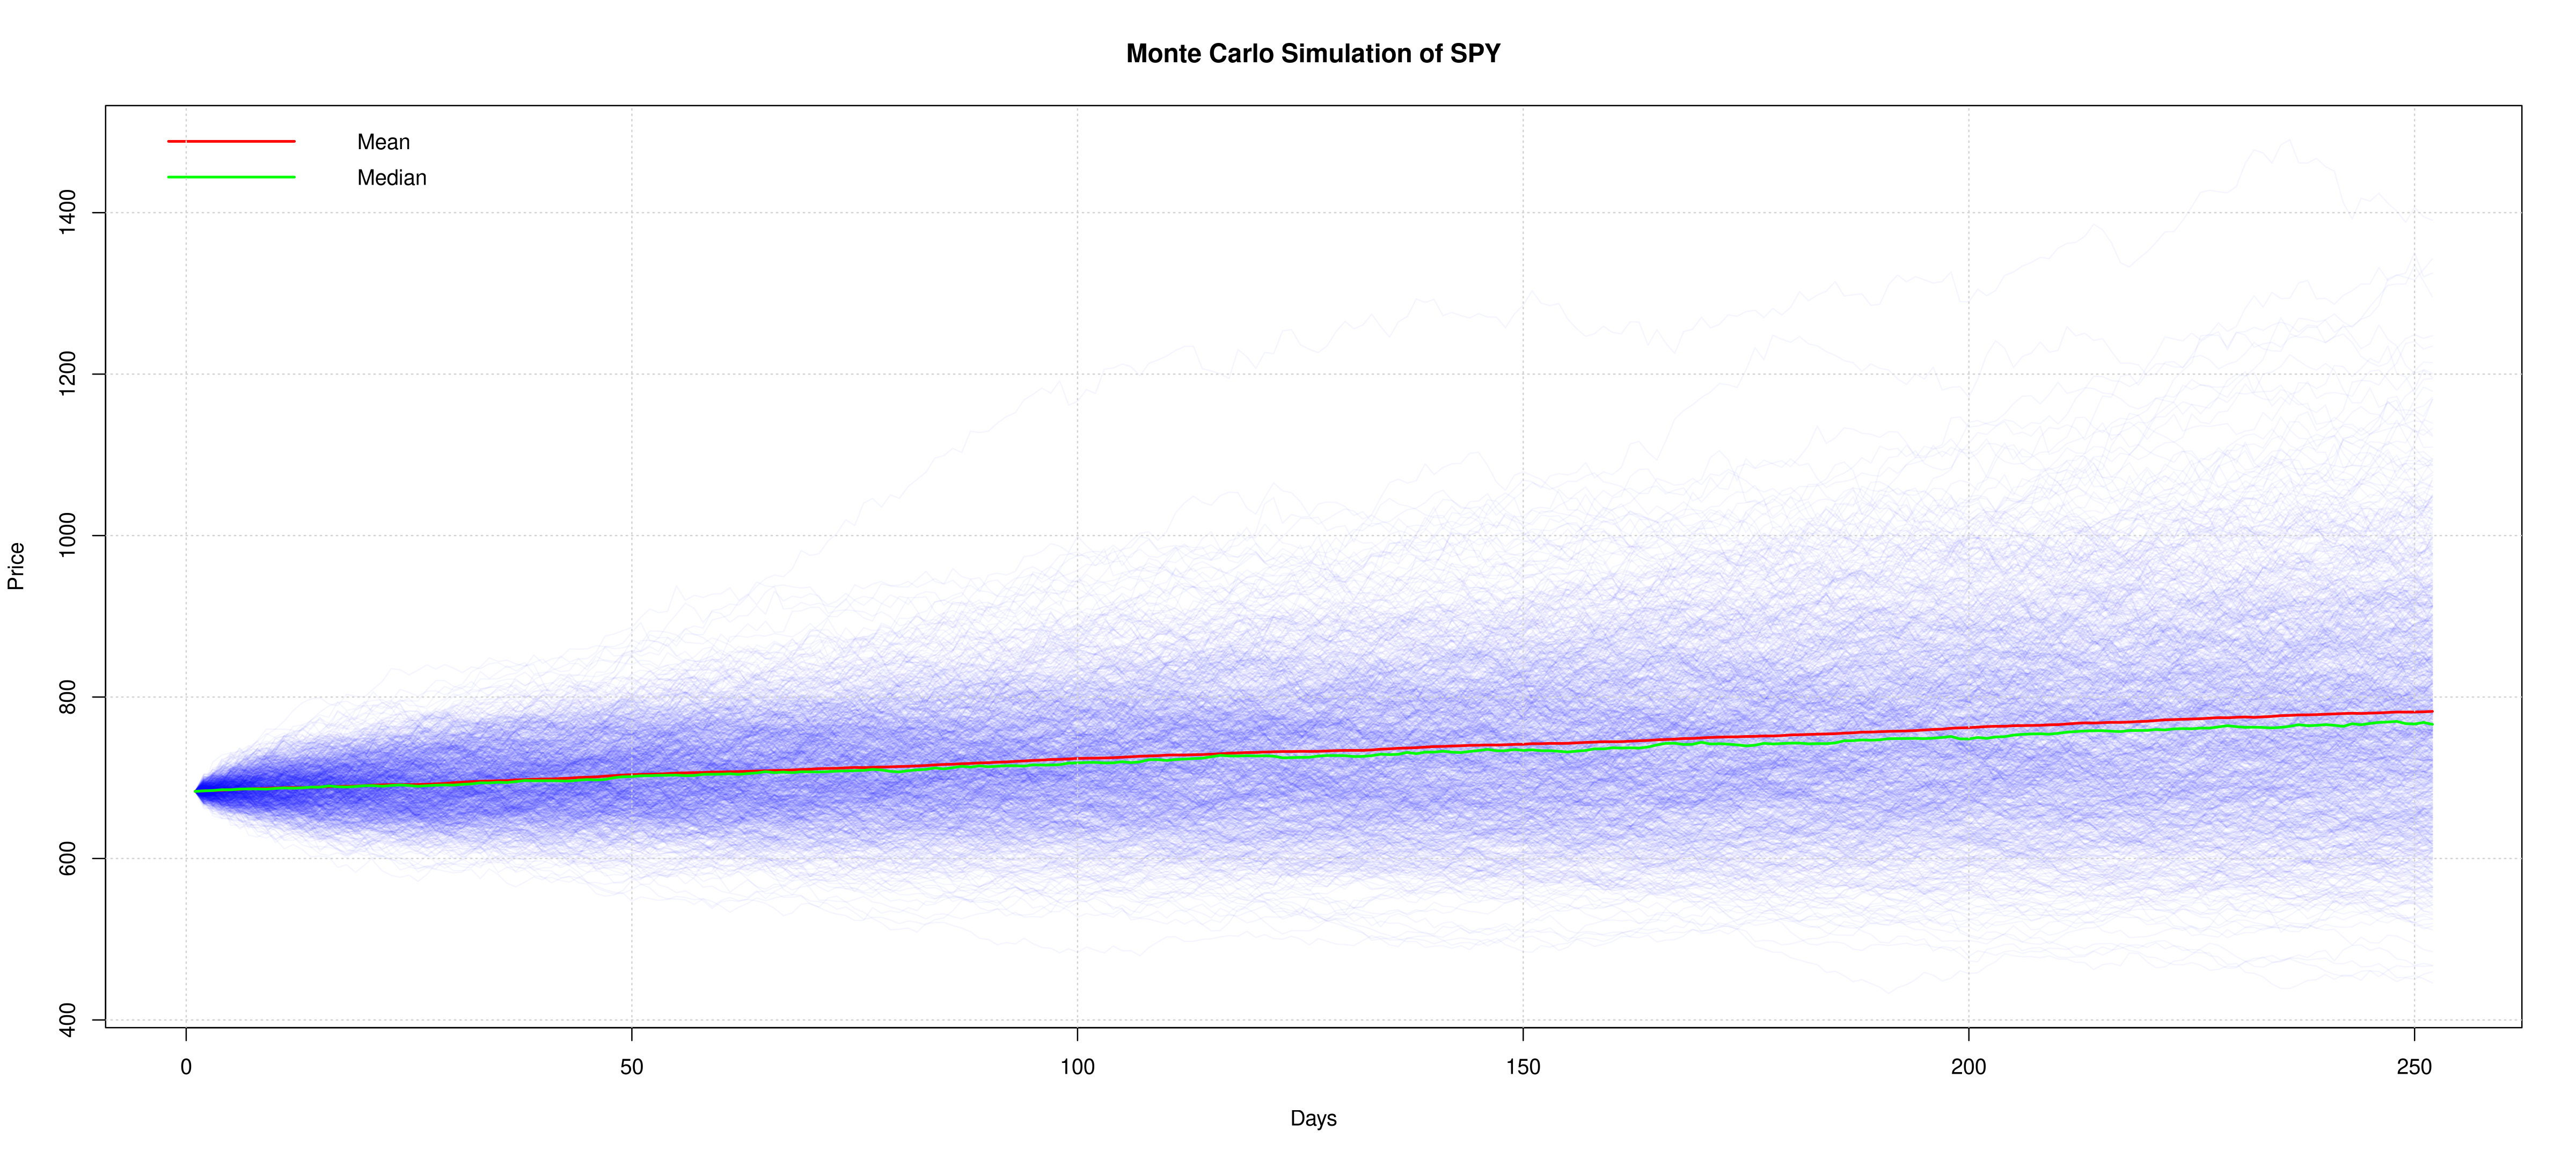

In [13]:
matplot(price_paths_v[, 1:num_paths], type = "l", lty = 1,
        col  = rgb(0, 0, 1, 0.04),
        main = "Monte Carlo Simulation of SPY",
        xlab = "Days", ylab = "Price")
lines(price_paths_v$Mean,   col = "red",   lwd = 2)
lines(price_paths_v$Median, col = "green", lwd = 2)
legend("topleft", legend = c("Mean","Median"),
       col = c("red","green"), lwd = 2, bty = "n")
grid()

## Histogram of the terminal values (last day) of the simulation

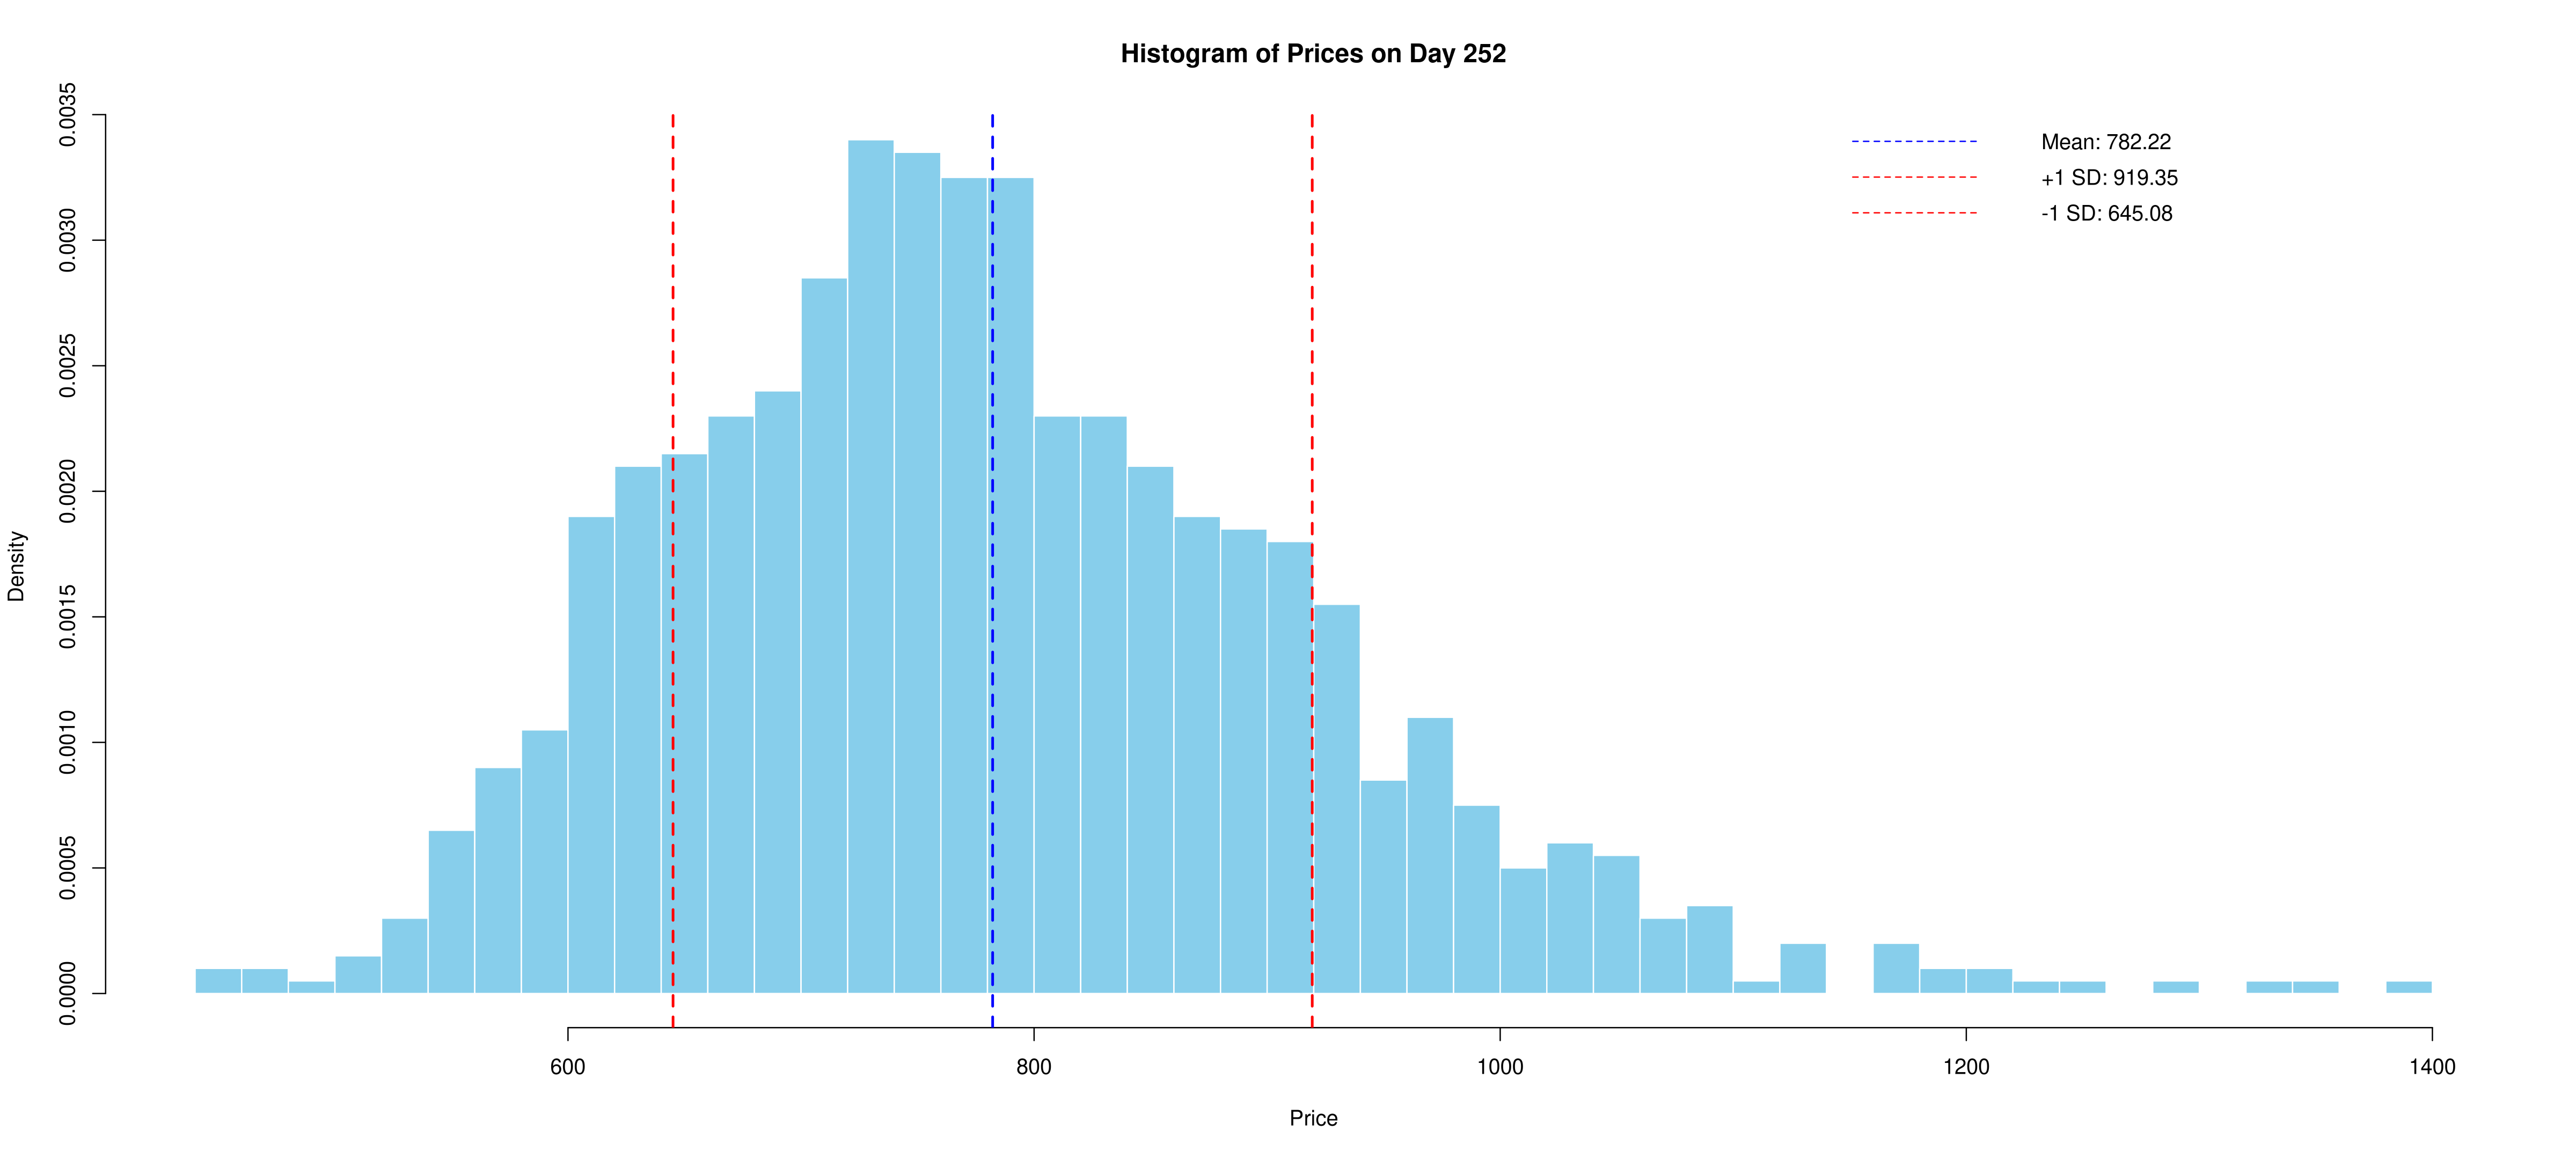

In [14]:
terminal <- unlist(price_paths_v[num_days, 1:num_paths])
mean_val <- mean(terminal)
std_val  <- sd(terminal)

hist(terminal, breaks = 50, col = "skyblue", border = "white",
     main = paste0("Histogram of Prices on Day ", num_days),
     xlab = "Price", freq = FALSE)
abline(v = mean_val,           col = "blue", lty = 2, lwd = 2)
abline(v = mean_val + std_val, col = "red",  lty = 2, lwd = 2)
abline(v = mean_val - std_val, col = "red",  lty = 2, lwd = 2)
legend("topright",
       legend = c(sprintf("Mean: %.2f", mean_val),
                  sprintf("+1 SD: %.2f", mean_val + std_val),
                  sprintf("-1 SD: %.2f", mean_val - std_val)),
       col = c("blue","red","red"), lty = 2, bty = "n")

### Conclusion:
- This method is best suited for index/ETF instruments
- Mean and standard deviation are assumed constant throughout the generative path
- Unable to model structural breaks or sudden jumps (e.g., earnings surprises on individual stocks)